In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization (for later modules)
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model saving/loading
import joblib

# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")


In [3]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Plot style
plt.style.use("seaborn-v0_8")


In [4]:
import sklearn
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)


Pandas version: 2.2.2
NumPy version: 2.0.2
Scikit-learn version: 1.6.1


In [5]:
# Load dataset
df = pd.read_csv("expenses_income_summary.csv")

# Show dataset shape
print("Dataset shape:", df.shape)


Dataset shape: (1155, 15)


In [6]:
# Display first 5 rows
df.head()


,Date,title,category,account,amount,currency,type,transfer-amount,transfer-currency,to-account,receive-amount,receive-currency,description,due-date,id
0,2024-08-11 13:56:59.652,Karthik,Bills & Fees,Savings Bank,45.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74e78631-db14-4495-bfb9-85546b0bd2fe
1,2024-08-10 16:09:55.986,Juice,Food & Drinks,Cash,40.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65e12e62-9f63-4c6c-b452-6c7b42fbfb7f
2,2024-08-09 10:25:21.618,Tire,Transport,Cash,10.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9ecd93bd-a835-4263-86e2-99fea475fa37
3,2024-08-07 03:57:24.944,Baba,Bills & Fees,Savings Bank,200.00,INR,EXPENSE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00d39b2c-e722-485a-85ca-28f6506dc674
4,2024-08-04 13:09:08.452,Reward,Bills & Fees,Salary Bank,4.00,INR,INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861d205-3245-4926-ad69-4491b0bff547


In [7]:
# Show all column names
df.columns


Index(['Date', 'title', 'category', 'account', 'amount', 'currency', 'type',
       'transfer-amount', 'transfer-currency', 'to-account', 'receive-amount',
       'receive-currency', 'description', 'due-date', 'id'],
      dtype='object')

In [8]:
# Dataset summary
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1155 non-null   object 
 1   title              1131 non-null   object 
 2   category           994 non-null    object 
 3   account            1155 non-null   object 
 4   amount             1155 non-null   object 
 5   currency           1155 non-null   object 
 6   type               1155 non-null   object 
 7   transfer-amount    44 non-null     object 
 8   transfer-currency  44 non-null     object 
 9   to-account         44 non-null     object 
 10  receive-amount     44 non-null     object 
 11  receive-currency   44 non-null     object 
 12  description        1 non-null      float64
 13  due-date           0 non-null      float64
 14  id                 1155 non-null   object 
dtypes: float64(2), object(13)
memory usage: 135.5+ KB


In [9]:
# Check missing values in each column
df.isnull().sum()


,0
Date,0
title,24
category,161
account,0
amount,0
currency,0
type,0
transfer-amount,1111
transfer-currency,1111
to-account,1111


In [10]:
df["type"].value_counts()


,count
type,
EXPENSE,1008
INCOME,103
TRANSFER,44


In [11]:
df["category"].value_counts().head(10)


,count
category,
Transport,429
Bills & Fees,287
Food & Drinks,278


In [12]:
df["amount"].describe()


,amount
count,1155
unique,185
top,20.00
freq,162


In [14]:
df.columns


Index(['Date', 'title', 'category', 'account', 'amount', 'currency', 'type',
       'transfer-amount', 'transfer-currency', 'to-account', 'receive-amount',
       'receive-currency', 'description', 'due-date', 'id'],
      dtype='object')

In [15]:
# Convert all column names to lowercase
df.columns = df.columns.str.lower()

# Check again
df.columns


Index(['date', 'title', 'category', 'account', 'amount', 'currency', 'type',
       'transfer-amount', 'transfer-currency', 'to-account', 'receive-amount',
       'receive-currency', 'description', 'due-date', 'id'],
      dtype='object')

In [16]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["date"].min(), df["date"].max()


(Timestamp('2023-04-22 06:58:13.959000'),
 Timestamp('2024-08-11 13:56:59.652000'))

In [17]:
df.columns


Index(['date', 'title', 'category', 'account', 'amount', 'currency', 'type',
       'transfer-amount', 'transfer-currency', 'to-account', 'receive-amount',
       'receive-currency', 'description', 'due-date', 'id'],
      dtype='object')

In [18]:
# Remove TRANSFER rows
df = df[df["type"] != "TRANSFER"]

# Check remaining transaction types
df["type"].value_counts()


,count
type,
EXPENSE,1008
INCOME,103


In [19]:
columns_to_drop = [
    "transfer-amount",
    "transfer-currency",
    "to-account",
    "receive-amount",
    "receive-currency",
    "due-date",
    "description"
]

df = df.drop(columns=columns_to_drop)


In [20]:
df["category"] = df["category"].fillna("Other")


In [21]:
df["title"] = df["title"].fillna("Unknown")


In [22]:
df.isnull().sum()


,0
date,0
title,0
category,0
account,0
amount,0
currency,0
type,0
id,0


In [23]:
print("Clean dataset shape:", df.shape)
df.head()


Clean dataset shape: (1111, 8)


,date,title,category,account,amount,currency,type,id
0,2024-08-11 13:56:59.652,Karthik,Bills & Fees,Savings Bank,45.00,INR,EXPENSE,74e78631-db14-4495-bfb9-85546b0bd2fe
1,2024-08-10 16:09:55.986,Juice,Food & Drinks,Cash,40.00,INR,EXPENSE,65e12e62-9f63-4c6c-b452-6c7b42fbfb7f
2,2024-08-09 10:25:21.618,Tire,Transport,Cash,10.00,INR,EXPENSE,9ecd93bd-a835-4263-86e2-99fea475fa37
3,2024-08-07 03:57:24.944,Baba,Bills & Fees,Savings Bank,200.00,INR,EXPENSE,00d39b2c-e722-485a-85ca-28f6506dc674
4,2024-08-04 13:09:08.452,Reward,Bills & Fees,Salary Bank,4.00,INR,INCOME,3861d205-3245-4926-ad69-4491b0bff547


In [24]:
df["date"] = pd.to_datetime(df["date"])


In [25]:
df["year_month"] = df["date"].dt.to_period("M")


In [26]:
df["year_month"].value_counts().sort_index()


,count
year_month,
2023-04,50
2023-05,65
2023-06,28
2023-07,32
2023-08,37
2023-09,52
2023-10,59
2023-11,89
2023-12,99


In [27]:
df[["date", "year_month", "amount", "type"]].head()


,date,year_month,amount,type
0,2024-08-11 13:56:59.652,2024-08,45.00,EXPENSE
1,2024-08-10 16:09:55.986,2024-08,40.00,EXPENSE
2,2024-08-09 10:25:21.618,2024-08,10.00,EXPENSE
3,2024-08-07 03:57:24.944,2024-08,200.00,EXPENSE
4,2024-08-04 13:09:08.452,2024-08,4.00,INCOME


MODULE: 6


In [34]:
df["date"] = pd.to_datetime(df["date"])
df["year_month"] = df["date"].dt.to_period("M")


In [35]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df["amount"] = df["amount"].fillna(0)


In [36]:
income_df = df[df["type"] == "INCOME"]
expense_df = df[df["type"] == "EXPENSE"]


In [37]:
monthly_income = (
    income_df
    .groupby("year_month")["amount"]
    .sum()
    .rename("total_income")
)


In [38]:
monthly_expense = (
    expense_df
    .groupby("year_month")["amount"]
    .sum()
    .rename("total_expense")
)


In [39]:
monthly_df = pd.concat([monthly_income, monthly_expense], axis=1).fillna(0)
monthly_df.reset_index(inplace=True)


In [40]:
monthly_df.head()


,year_month,total_income,total_expense
0,2023-04,1126.64,2296.60
1,2023-05,480.43,2458.00
2,2023-06,3.00,1988.27
3,2023-07,394.00,967.00
4,2023-08,900.00,1565.00


In [41]:
monthly_df["total_income"] = pd.to_numeric(monthly_df["total_income"], errors="coerce")
monthly_df["total_expense"] = pd.to_numeric(monthly_df["total_expense"], errors="coerce")

monthly_df[["total_income", "total_expense"]] = (
    monthly_df[["total_income", "total_expense"]].fillna(0)
)


In [42]:
monthly_df["expense_ratio"] = (
    monthly_df["total_expense"] /
    monthly_df["total_income"].replace(0, 1)
)

monthly_df["savings_rate"] = (
    (monthly_df["total_income"] - monthly_df["total_expense"]) /
    monthly_df["total_income"].replace(0, 1)
)


In [43]:
food_expense = (
    expense_df[expense_df["category"].str.contains("Food", case=False, na=False)]
    .groupby("year_month")["amount"]
    .sum()
)


In [44]:
shopping_expense = (
    expense_df[expense_df["category"].str.contains("Shop", case=False, na=False)]
    .groupby("year_month")["amount"]
    .sum()
)


In [45]:
monthly_df = monthly_df.set_index("year_month")

monthly_df["food_pct"] = (
    food_expense / monthly_df["total_expense"]
).fillna(0)

monthly_df["shopping_pct"] = (
    shopping_expense / monthly_df["total_expense"]
).fillna(0)

monthly_df.reset_index(inplace=True)


In [46]:
monthly_df


,year_month,total_income,total_expense,expense_ratio,savings_rate,food_pct,shopping_pct
0,2023-04,1126.64,2296.60,2.038451,-1.038451,0.198554,0.0
1,2023-05,480.43,2458.00,5.116250,-4.116250,0.205452,0.0
2,2023-06,3.00,1988.27,662.756667,-661.756667,0.088016,0.0
3,2023-07,394.00,967.00,2.454315,-1.454315,0.279214,0.0
4,2023-08,900.00,1565.00,1.738889,-0.738889,0.105431,0.0
5,2023-09,33.00,2578.00,78.121212,-77.121212,0.217223,0.0
6,2023-10,978.00,3269.82,3.343374,-2.343374,0.237322,0.0
7,2023-11,33.20,7959.20,239.734940,-238.734940,0.372148,0.0
8,2023-12,2049.22,5988.10,2.922136,-1.922136,0.446085,0.0
9,2024-01,642.00,6342.12,9.878692,-8.878692,0.251493,0.0


Module:7
Overspend = 1 if:
   expense_ratio > 1.0
   AND
   savings_rate < 0
Else:
   overspend = 0




In [64]:
monthly_df["risk_score"] = (
    monthly_df["expense_ratio"] +
    (monthly_df["food_pct"] * 2) -
    (monthly_df["savings_rate"])
)


In [65]:
low_th = monthly_df["risk_score"].quantile(0.33)
high_th = monthly_df["risk_score"].quantile(0.66)


In [66]:
def assign_risk(score):
    if score <= low_th:
        return 0   # LOW (best months for this user)
    elif score <= high_th:
        return 1   # MEDIUM
    else:
        return 2   # HIGH

monthly_df["risk_level"] = monthly_df["risk_score"].apply(assign_risk)


In [67]:
monthly_df["risk_level"].value_counts().sort_index()


,count
risk_level,
0,6
1,5
2,6


Module:8


In [68]:
features = [
    "total_income",
    "total_expense",
    "expense_ratio",
    "savings_rate",
    "food_pct",
    "shopping_pct"
]

X = monthly_df[features]
y = monthly_df["risk_level"]


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    class_weight="balanced"
)


In [71]:
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [72]:
rf_model.predict(X_test)


array([2, 1, 0, 0, 2, 2])

module 9

In [73]:
y_pred = rf_model.predict(X_test)


In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      0.50      0.67         2
           2       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6



In [75]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)


array([[2, 0, 0],
       [0, 1, 1],
       [0, 0, 2]])

In [76]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
balanced_accuracy


np.float64(0.8333333333333334)

In [77]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_test, y_pred, average="macro")
macro_f1


0.8222222222222223

In [78]:
accuracy_score(y_test, y_pred)


0.8333333333333334

module 10

In [79]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance


,feature,importance
3,savings_rate,0.278053
2,expense_ratio,0.260880
0,total_income,0.205745
1,total_expense,0.188178
4,food_pct,0.067143
5,shopping_pct,0.000000


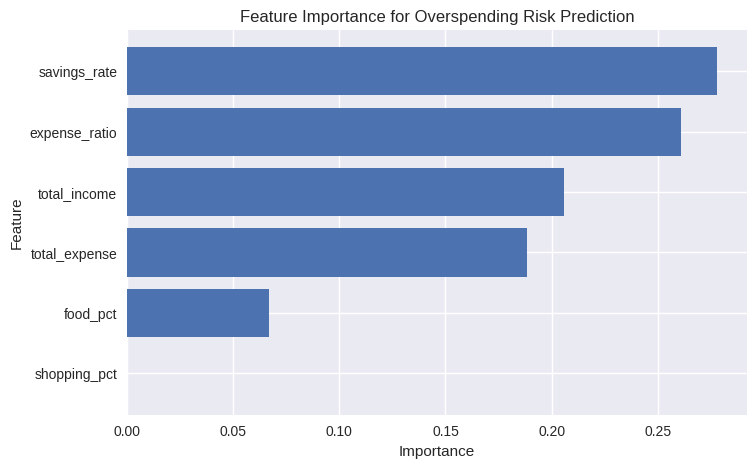

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Overspending Risk Prediction")
plt.gca().invert_yaxis()
plt.show()


In [81]:
def generate_ai_advice(row, prediction):
    advice = []

    if prediction == 2:
        advice.append("High overspending risk detected.")
    elif prediction == 1:
        advice.append("Moderate overspending risk detected.")
    else:
        advice.append("Spending is under control.")

    if row["food_pct"] > 0.3:
        advice.append("Food expenses are significantly high.")

    if row["shopping_pct"] > 0.2:
        advice.append("Shopping expenses are contributing to overspending.")

    if row["savings_rate"] < 0:
        advice.append("You are spending more than your income.")

    return advice


module 11


In [82]:
import joblib

joblib.dump(rf_model, "overspending_risk_model.pkl")


['overspending_risk_model.pkl']

In [83]:
joblib.dump(features, "model_features.pkl")


['model_features.pkl']

In [84]:
loaded_model = joblib.load("overspending_risk_model.pkl")
loaded_features = joblib.load("model_features.pkl")


In [85]:
def predict_risk(input_dict):
    """
    input_dict example:
    {
        "total_income": 12000,
        "total_expense": 15000,
        "expense_ratio": 1.25,
        "savings_rate": -0.25,
        "food_pct": 0.32,
        "shopping_pct": 0.10
    }
    """
    import pandas as pd

    input_df = pd.DataFrame([input_dict])
    input_df = input_df[loaded_features]  # ensure correct order

    prediction = loaded_model.predict(input_df)[0]
    return int(prediction)


In [86]:
sample_input = {
    "total_income": 8000,
    "total_expense": 12000,
    "expense_ratio": 1.5,
    "savings_rate": -0.5,
    "food_pct": 0.35,
    "shopping_pct": 0.15
}

predict_risk(sample_input)


0

In [87]:
def map_risk_to_ui(pred):
    if pred == 2:
        return "🚨 High Overspending Risk"
    elif pred == 1:
        return "⚠️ Moderate Overspending Risk"
    else:
        return "✅ Spending Under Control"


module 12